# Thesis Part 3
## ViT + Adapter Modules + EWC TIL CL

### What this notebook does:
- Same frozen ViT backbone + adapter modules as Notebook 2
- After training on each task, computes the **Fisher Information Matrix** on the adapter parameters only
- During the next task, applies an **EWC penalty** to prevent important adapter weights from drifting
- EWC is applied ONLY to adapter weights and not the frozen backbone (which never changes anyway)

### Why EWC on adapter weights?
Even though the backbone is frozen, the adapter weights are shared across all tasks.
When Task 2 trains, it updates the same adapter weights that Task 1 trained.
EWC penalises changes to adapter weights that were important for previous tasks,
reducing the remaining 21.26% forgetting observed in Notebook 2.

### EWC Loss:
```
L_total = L_task + (lambda/2) * sum_i [ F_i * (theta_i - theta_i*)^2 ]
```
Where:
- L_task = cross entropy loss on current task
- F_i = Fisher Information (importance) of adapter parameter i
- theta_i* = adapter parameter values after previous task
- lambda = regularisation strength (controls stability vs plasticity)

In [ ]:
!pip install timm -q

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import timm
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [ ]:
import random

def set_seed(seed=42):
    """Fix all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f'Seed set to {seed}')

set_seed(42)

Seed set to 42


## Data Preparation
Identical to Notebooks 1 and 2.

In [ ]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

train_dataset = datasets.CIFAR100(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

NUM_TASKS        = 5
CLASSES_PER_TASK = 100 // NUM_TASKS  # 20

def create_tasks(dataset, num_tasks=NUM_TASKS):
    tasks = []
    classes_per_task = []
    targets = np.array(dataset.targets)
    for i in range(num_tasks):
        class_range = list(range(i * CLASSES_PER_TASK, (i + 1) * CLASSES_PER_TASK))
        idx = np.isin(targets, class_range).nonzero()[0]
        tasks.append(Subset(dataset, idx))
        classes_per_task.append(class_range)
    return tasks, classes_per_task

train_tasks, classes_per_task = create_tasks(train_dataset)
test_tasks,  _                = create_tasks(test_dataset)

print(f'Tasks: {NUM_TASKS}, Classes per task: {CLASSES_PER_TASK}')
print(f'Train samples per task: {len(train_tasks[0])}')

100%|██████████| 169M/169M [00:03<00:00, 46.8MB/s]


Tasks: 5, Classes per task: 20
Train samples per task: 10000


## Adapter Module
Same architecture as Notebook 2.

In [ ]:
class AdapterModule(nn.Module):
    """
    Bottleneck adapter: LayerNorm -> Linear(d->b) -> GELU -> Linear(b->d) -> residual
    """
    def __init__(self, d_model=192, bottleneck_dim=64):
        super().__init__()
        self.norm       = nn.LayerNorm(d_model)
        self.down_proj  = nn.Linear(d_model, bottleneck_dim)
        self.activation = nn.GELU()
        self.up_proj    = nn.Linear(bottleneck_dim, d_model)
        nn.init.zeros_(self.up_proj.weight)
        nn.init.zeros_(self.up_proj.bias)

    def forward(self, x):
        residual = x
        x = self.norm(x)
        x = self.down_proj(x)
        x = self.activation(x)
        x = self.up_proj(x)
        return x + residual

## ViT with Adapters
Same as Notebook 2 with frozen backbone, trainable adapters + head.

In [ ]:
class ViTWithAdapters(nn.Module):
    def __init__(self, num_classes=100, bottleneck_dim=64):
        super().__init__()
        self.vit = timm.create_model(
            'vit_tiny_patch16_224',
            pretrained=True,
            num_classes=num_classes
        )
        # Freeze backbone
        for param in self.vit.parameters():
            param.requires_grad = False
        # Unfreeze head
        for param in self.vit.head.parameters():
            param.requires_grad = True

        d_model    = self.vit.embed_dim
        num_blocks = len(self.vit.blocks)
        self.adapters = nn.ModuleList([
            AdapterModule(d_model=d_model, bottleneck_dim=bottleneck_dim)
            for _ in range(num_blocks)
        ])

        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'ViT backbone frozen. Blocks: {num_blocks}, d_model: {d_model}')
        print(f'Total params    : {total:,}')
        print(f'Trainable params: {trainable:,}  ({100*trainable/total:.1f}%)')
        print(f'Frozen params   : {total-trainable:,}  ({100*(total-trainable)/total:.1f}%)')

    def forward(self, x):
        x = self.vit.patch_embed(x)
        x = self.vit._pos_embed(x)
        x = self.vit.patch_drop(x)
        x = self.vit.norm_pre(x)
        for i, block in enumerate(self.vit.blocks):
            x = block(x)
            x = self.adapters[i](x)
        x = self.vit.norm(x)
        x = self.vit.forward_head(x)
        return x

## EWC — Elastic Weight Consolidation

### How it works step by step:

**Step 1 — After finishing task t, compute Fisher Information for each adapter parameter:**
```
F_i = E[ (d log p(y|x) / d theta_i)^2 ]
```
In practice it can be  approximated by running the training data through the model
and averaging the squared gradients of the log-likelihood.
A high F_i means parameter i was important for task t and changing it will hurt performance.

**Step 2 — Save the current adapter parameter values as the anchor (theta*):**
These are the "good" values we want to stay close to.

**Step 3 — During task t+1 training, add EWC penalty to the loss:**
```
L_total = L_task + (lambda/2) * sum_i [ F_i * (theta_i - theta_i*)^2 ]
```
Parameters with high Fisher importance are penalised heavily if they move far from theta*.
Parameters with low importance can move freely to learn the new task.

### Key design choice: EWC on adapter weights ONLY
Do not apply EWC to the frozen backbone (those weights never change anyway).
Apply EWC only to the 321K trainable adapter + head parameters.
This makes the regularisation targeted and computationally efficient.

In [ ]:
class EWC:
    """
    Elastic Weight Consolidation applied to adapter + head parameters only.

    Usage:
        # After training task t:
        ewc = EWC(model, train_data_t, device)

        # During task t+1 training:
        loss = criterion(outputs, labels) + ewc.penalty(model)
    """

    def __init__(self, model, dataset, device, n_samples=500):
        """
        Compute Fisher Information and save parameter anchors.

        Args:
            model    : trained ViTWithAdapters model after task t
            dataset  : training dataset for task t
            device   : cuda or cpu
            n_samples: number of samples to estimate Fisher (500 is enough)
        """
        self.device = device
        self.params = {}   # anchor values: theta_i*
        self.fisher = {}   # Fisher Information: F_i

        # Save current parameter values as anchors
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.params[name] = param.data.clone()

        # Compute Fisher Information via squared gradients
        self._compute_fisher(model, dataset, n_samples)

    def _compute_fisher(self, model, dataset, n_samples):
        """Approximate Fisher Information using squared gradients of log-likelihood."""
        model.eval()

        # Initialise Fisher accumulators at zero
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.fisher[name] = torch.zeros_like(param.data)

        # Sample a subset of training data
        indices   = torch.randperm(len(dataset))[:n_samples]
        subset    = Subset(dataset, indices)
        loader    = DataLoader(subset, batch_size=32, shuffle=False)
        criterion = nn.CrossEntropyLoss()
        n_batches = 0

        for images, labels in loader:
            images, labels = images.to(self.device), labels.to(self.device)
            model.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()

            # Accumulate squared gradients as Fisher estimate
            for name, param in model.named_parameters():
                if param.requires_grad and param.grad is not None:
                    self.fisher[name] += param.grad.data.clone() ** 2
            n_batches += 1

        # Normalise by number of batches
        for name in self.fisher:
            self.fisher[name] /= n_batches

        # Print Fisher stats for transparency
        total_fisher = sum(f.sum().item() for f in self.fisher.values())
        print(f'  Fisher computed over {n_samples} samples. Total importance: {total_fisher:.2f}')

    def penalty(self, model):
        """
        Compute EWC penalty: sum_i [ F_i * (theta_i - theta_i*)^2 ]
        This is added to the task loss during training.
        """
        loss = torch.tensor(0.0, device=self.device)
        for name, param in model.named_parameters():
            if param.requires_grad and name in self.fisher:
                fisher_val = self.fisher[name].to(self.device)
                anchor     = self.params[name].to(self.device)
                loss      += (fisher_val * (param - anchor) ** 2).sum()
        return loss

## Training with EWC

The training function now accepts a list of EWC objects (one per previous task).
The total loss is:
```
L_total = L_task + (lambda/2) * sum_{prev tasks} EWC_penalty
```
For Task 1 there are no previous tasks so EWC has no effect and training is identical to Notebook 2.
From Task 2 onwards, EWC penalties accumulate from all previous tasks.

In [ ]:
# EWC regularisation strength
# Higher = more stability (less forgetting) but less plasticity (harder to learn new tasks)
# 1000 is a commonly used starting value in the literature
EWC_LAMBDA = 1000

def train_with_ewc(model, train_data, ewc_list, epochs=10, lr=1e-3, ewc_lambda=EWC_LAMBDA):
    """
    Train model with EWC regularisation.

    Args:
        model      : ViTWithAdapters
        train_data : current task dataset
        ewc_list   : list of EWC objects from all previous tasks
        epochs     : training epochs
        lr         : learning rate
        ewc_lambda : regularisation strength
    """
    model.train()
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer  = optim.Adam(trainable_params, lr=lr)
    criterion  = nn.CrossEntropyLoss()
    dataloader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2)

    for epoch in range(epochs):
        running_task_loss = 0.0
        running_ewc_loss  = 0.0

        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs   = model(images)
            task_loss = criterion(outputs, labels)

            # Add EWC penalty from all previous tasks
            ewc_loss = torch.tensor(0.0, device=device)
            for ewc in ewc_list:
                ewc_loss += ewc_lambda / 2 * ewc.penalty(model)

            total_loss = task_loss + ewc_loss
            total_loss.backward()
            optimizer.step()

            running_task_loss += task_loss.item()
            running_ewc_loss  += ewc_loss.item()

        n = len(dataloader)
        print(f'  Epoch {epoch+1}/{epochs} — '
              f'Task Loss: {running_task_loss/n:.4f} | '
              f'EWC Loss: {running_ewc_loss/n:.4f} | '
              f'Total: {(running_task_loss+running_ewc_loss)/n:.4f}')

## Evaluation Functions and Metrics
Identical to Notebooks 1 and 2.

In [ ]:
def evaluate_task(model, task_data, task_classes):
    model.eval()
    correct, total = 0, 0
    dataloader = DataLoader(task_data, batch_size=64, num_workers=2)
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs      = model(images)
            outputs_task = outputs[:, task_classes]
            # Vectorised label mapping: faster than list .index() loop
            label_map = torch.full((100,), -1, dtype=torch.long)
            for local_idx, global_idx in enumerate(task_classes):
                label_map[global_idx] = local_idx
            labels_local = label_map[labels.cpu()].to(device)
            _, preds = torch.max(outputs_task, 1)
            correct += (preds == labels_local).sum().item()
            total   += labels.size(0)
    return correct / total * 100


def evaluate_all_tasks(model, test_tasks, classes_per_task, num_seen):
    return [
        evaluate_task(model, test_tasks[t], classes_per_task[t])
        for t in range(num_seen)
    ]


def compute_metrics(acc_matrix):
    T    = len(acc_matrix)
    full = np.full((T, T), np.nan)
    for t in range(T):
        for i in range(len(acc_matrix[t])):
            full[t][i] = acc_matrix[t][i]
    avg_acc   = np.nanmean(full[T - 1])
    forgetting = [np.nanmax(full[:, i]) - full[T-1][i] for i in range(T - 1)]
    f_avg     = np.mean(forgetting)
    bwt       = np.mean([full[T-1][i] - full[i][i] for i in range(T - 1)])
    return avg_acc, f_avg, bwt, forgetting

## Run: ViT + Adapters + EWC

Training loop:
1. Train on task t using EWC penalties from all previous tasks
2. Evaluate on all tasks seen so far
3. Compute Fisher Information on task t training data
4. Save EWC object for task t
5. Move to task t+1

In [ ]:
# Build model
vit_ewc = ViTWithAdapters(num_classes=100, bottleneck_dim=64).to(device)

ewc_list       = []   # grows after each task
ewc_acc_matrix = []

for t_id in range(NUM_TASKS):
    print(f'\n--- ViT+Adapters+EWC: Training on Task {t_id + 1}/{NUM_TASKS} ---')
    print(f'  Active EWC constraints: {len(ewc_list)}')

    # Train with EWC penalty from all previous tasks
    train_with_ewc(vit_ewc, train_tasks[t_id], ewc_list, epochs=10, lr=1e-3)

    # Evaluate on all tasks seen so far
    accs = evaluate_all_tasks(vit_ewc, test_tasks, classes_per_task, num_seen=t_id + 1)
    ewc_acc_matrix.append(accs)
    print(f'  Accuracies after Task {t_id + 1}: {[f"{a:.2f}" for a in accs]}')

    # Compute Fisher Information on current task data and store EWC object
    print(f'  Computing Fisher Information for Task {t_id + 1}...')
    ewc = EWC(vit_ewc, train_tasks[t_id], device, n_samples=500)
    ewc_list.append(ewc)

ewc_avg_acc, ewc_f_avg, ewc_bwt, ewc_forgetting = compute_metrics(ewc_acc_matrix)

print('\n=== ViT + Adapters + EWC Final Results ===')
print(f'  Average Accuracy  : {ewc_avg_acc:.2f}%')
print(f'  Average Forgetting: {ewc_f_avg:.2f}%')
print(f'  Backward Transfer : {ewc_bwt:.2f}%')
print(f'  Per-task Forgetting: {[f"{f:.2f}" for f in ewc_forgetting]}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

ViT backbone frozen. Blocks: 12, d_model: 192
Total params    : 5,846,308
Trainable params: 321,892  (5.5%)
Frozen params   : 5,524,416  (94.5%)

--- ViT+Adapters+EWC: Training on Task 1/5 ---
  Active EWC constraints: 0
  Epoch 1/10 — Task Loss: 0.6691 | EWC Loss: 0.0000 | Total: 0.6691
  Epoch 2/10 — Task Loss: 0.1712 | EWC Loss: 0.0000 | Total: 0.1712
  Epoch 3/10 — Task Loss: 0.0918 | EWC Loss: 0.0000 | Total: 0.0918
  Epoch 4/10 — Task Loss: 0.0603 | EWC Loss: 0.0000 | Total: 0.0603
  Epoch 5/10 — Task Loss: 0.0430 | EWC Loss: 0.0000 | Total: 0.0430
  Epoch 6/10 — Task Loss: 0.0205 | EWC Loss: 0.0000 | Total: 0.0205
  Epoch 7/10 — Task Loss: 0.0527 | EWC Loss: 0.0000 | Total: 0.0527
  Epoch 8/10 — Task Loss: 0.0470 | EWC Loss: 0.0000 | Total: 0.0470
  Epoch 9/10 — Task Loss: 0.0329 | EWC Loss: 0.0000 | Total: 0.0329
  Epoch 10/10 — Task Loss: 0.0305 | EWC Loss: 0.0000 | Total: 0.0305
  Accuracies after Task 1: ['92.40']
  Computing Fisher Information for Task 1...
  Fisher compute

## Full Comparison Table
All 4 models side by side.

In [ ]:
# Results from Notebooks 1 and 2
resnet_avg_acc  = 24.22;  resnet_f_avg  = 69.17;  resnet_bwt  = -69.17
vit_avg_acc     = 41.91;  vit_f_avg     = 63.26;  vit_bwt     = -63.26
adapter_avg_acc = 76.93;  adapter_f_avg = 19.91;  adapter_bwt = -19.91

print('\n' + '='*75)
print(f'{"Metric":<30} {"ResNet-18":>10} {"ViT-Tiny":>10} {"ViT+Adapt":>10} {"Adapt+EWC":>10}')
print('='*75)
print(f'{"Average Accuracy (%)":<30} {resnet_avg_acc:>10.2f} {vit_avg_acc:>10.2f} {adapter_avg_acc:>10.2f} {ewc_avg_acc:>10.2f}')
print(f'{"Average Forgetting (%)":<30} {resnet_f_avg:>10.2f} {vit_f_avg:>10.2f} {adapter_f_avg:>10.2f} {ewc_f_avg:>10.2f}')
print(f'{"Backward Transfer (%)":<30} {resnet_bwt:>10.2f} {vit_bwt:>10.2f} {adapter_bwt:>10.2f} {ewc_bwt:>10.2f}')
print('='*75)

# Improvement summary
print('\n--- Forgetting Reduction vs Baselines ---')
print(f'  Adapters+EWC vs ResNet   : -{resnet_f_avg - ewc_f_avg:.2f}% forgetting')
print(f'  Adapters+EWC vs ViT      : -{vit_f_avg - ewc_f_avg:.2f}% forgetting')
print(f'  Adapters+EWC vs Adapters : -{adapter_f_avg - ewc_f_avg:.2f}% forgetting (EWC contribution)')


Metric                          ResNet-18   ViT-Tiny  ViT+Adapt  Adapt+EWC
Average Accuracy (%)                24.22      41.91      76.93      90.59
Average Forgetting (%)              69.17      63.26      19.91       2.01
Backward Transfer (%)              -69.17     -63.26     -19.91      -1.85

--- Forgetting Reduction vs Baselines ---
  Adapters+EWC vs ResNet   : -67.16% forgetting
  Adapters+EWC vs ViT      : -61.25% forgetting
  Adapters+EWC vs Adapters : -17.90% forgetting (EWC contribution)


## Visualisation — Full 4-Model Comparison

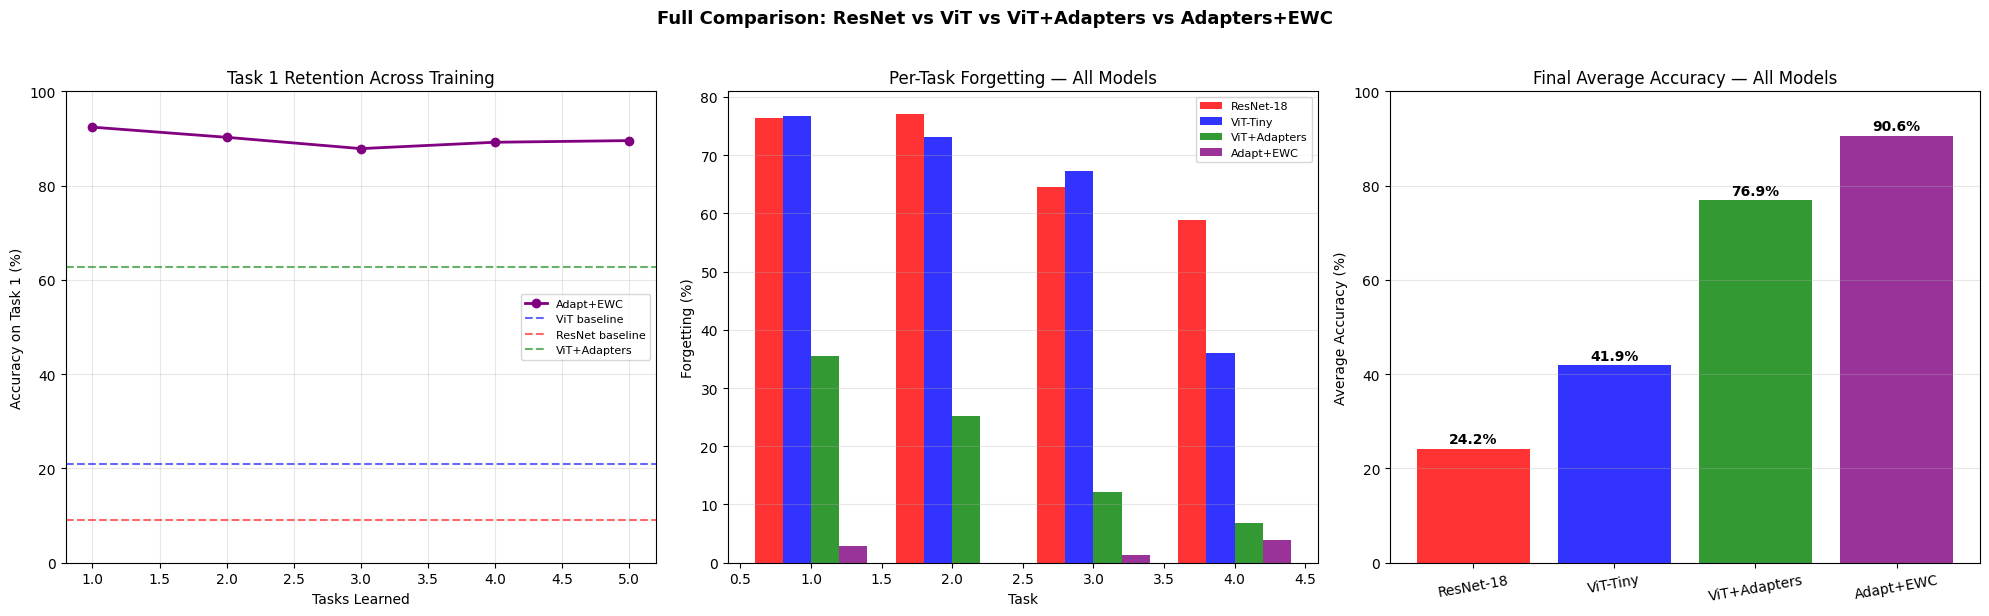

Figure saved as full_comparison.png


In [ ]:
# Per-task forgetting from Notebooks 1 and 2
resnet_forgetting  = [76.30, 77.10, 64.50, 58.80]
vit_forgetting     = [76.80, 73.10, 67.20, 35.95]
adapter_forgetting = [35.50, 25.25, 12.10, 6.80]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = {'ResNet-18': 'red', 'ViT-Tiny': 'blue',
          'ViT+Adapters': 'green', 'Adapt+EWC': 'purple'}

# Plot 1: Task 1 forgetting curve across all 4 models
ax = axes[0]
ewc_task1 = [ewc_acc_matrix[t][0] for t in range(NUM_TASKS)]
ax.plot(range(1, NUM_TASKS + 1), ewc_task1, 'o-', color='purple',
        label='Adapt+EWC', linewidth=2)
ax.axhline(y=20.90, color='blue',  linestyle='--', alpha=0.6, label='ViT baseline')
ax.axhline(y=9.10,  color='red',   linestyle='--', alpha=0.6, label='ResNet baseline')
ax.axhline(y=62.80, color='green', linestyle='--', alpha=0.6, label='ViT+Adapters')
ax.set_xlabel('Tasks Learned')
ax.set_ylabel('Accuracy on Task 1 (%)')
ax.set_title('Task 1 Retention Across Training')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)

# Plot 2: Per-task forgetting for all 4 models
ax = axes[1]
x     = np.arange(1, NUM_TASKS)
width = 0.2
ax.bar(x - 1.5*width, resnet_forgetting,  width, label='ResNet-18',    color='red',    alpha=0.8)
ax.bar(x - 0.5*width, vit_forgetting,     width, label='ViT-Tiny',     color='blue',   alpha=0.8)
ax.bar(x + 0.5*width, adapter_forgetting, width, label='ViT+Adapters', color='green',  alpha=0.8)
ax.bar(x + 1.5*width, ewc_forgetting,     width, label='Adapt+EWC',    color='purple', alpha=0.8)
ax.set_xlabel('Task')
ax.set_ylabel('Forgetting (%)')
ax.set_title('Per-Task Forgetting — All Models')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Final average accuracy for all 4 models
ax = axes[2]
model_names = ['ResNet-18', 'ViT-Tiny', 'ViT+Adapters', 'Adapt+EWC']
avg_accs    = [resnet_avg_acc, vit_avg_acc, adapter_avg_acc, ewc_avg_acc]
bar_colors  = ['red', 'blue', 'green', 'purple']
bars = ax.bar(model_names, avg_accs, color=bar_colors, alpha=0.8)
for bar, val in zip(bars, avg_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Average Accuracy (%)')
ax.set_title('Final Average Accuracy — All Models')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=10)

plt.suptitle('Full Comparison: ResNet vs ViT vs ViT+Adapters vs Adapters+EWC',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as full_comparison.png')